In [1]:
!pip install ultralytics -q

import os, time, json, shutil, zipfile
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from ultralytics import YOLO
from google.colab import drive

In [2]:
drive.mount('/content/drive', force_remount=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if device.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU détecté → Exécution > Modifier le type d'exécution > GPU")

Mounted at /content/drive
PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA A100-SXM4-80GB


In [3]:
PROJECT_DIR     = '/content/drive/MyDrive/pedestrian_detection'
JAAD_DIR        = f'{PROJECT_DIR}/JAAD'
VIDEOS_DIR      = f'{JAAD_DIR}/JAAD_clips'
ANNOTATIONS_DIR = f'{JAAD_DIR}/annotations'
DATASET_DIR     = f'{PROJECT_DIR}/dataset'
DRIVE_CROPS     = f'{DATASET_DIR}/crops'
LOCAL_CROPS     = '/content/dataset/crops'
MODELS_DIR      = f'{PROJECT_DIR}/models'
FIGURES_DIR     = f'{PROJECT_DIR}/figures_rapport'

for d in [PROJECT_DIR, DATASET_DIR, LOCAL_CROPS, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print("Chemins prêts. Projet :", PROJECT_DIR)

Chemins prêts. Projet : /content/drive/MyDrive/pedestrian_detection


In [4]:
if not os.path.exists(JAAD_DIR):
    %cd $PROJECT_DIR
    !git clone https://github.com/ykotseruba/JAAD.git
else:
    print("Dossier JAAD déjà présent, on saute le clone.")

if (not os.path.exists(VIDEOS_DIR)) or (len(os.listdir(VIDEOS_DIR)) == 0):
    %cd $JAAD_DIR
    !chmod +x download_clips.sh
    !bash download_clips.sh
else:
    print(f"Vidéos déjà présentes : {len(os.listdir(VIDEOS_DIR))} fichiers.")

%cd $PROJECT_DIR
print("Vidéos :", os.path.exists(VIDEOS_DIR), "| Annotations :", os.path.exists(ANNOTATIONS_DIR))

/content/drive/MyDrive/pedestrian_detection
Cloning into 'JAAD'...
remote: Enumerating objects: 6155, done.
remote: Counting objects: 100% (724/724), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 6155 (delta 672), reused 695 (delta 652), pack-reused 5431 (from 1)
Receiving objects: 100% (6155/6155), 42.16 MiB | 21.45 MiB/s, done.
Resolving deltas: 100% (5491/5491), done.
Updating files: 100% (1745/1745), done.
/content/drive/MyDrive/pedestrian_detection/JAAD
--2026-06-05 20:17:59--  http://data.nvision2.eecs.yorku.ca/JAAD_dataset/data/JAAD_clips.zip
Resolving data.nvision2.eecs.yorku.ca (data.nvision2.eecs.yorku.ca)... 130.63.94.247
Connecting to data.nvision2.eecs.yorku.ca (data.nvision2.eecs.yorku.ca)|130.63.94.247|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.nvision2.eecs.yorku.ca/JAAD_dataset/data/JAAD_clips.zip [following]
--2026-06-05 20:18:00--  https://data.nvision2.eecs.yorku.ca/JAAD_dataset/data/

In [5]:
all_attributes = defaultdict(Counter)
for xml_file in sorted(os.listdir(ANNOTATIONS_DIR)):
    try:
        root = ET.parse(os.path.join(ANNOTATIONS_DIR, xml_file)).getroot()
        for track in root.findall('track'):
            if 'ped' not in track.get('label', '').lower():
                continue
            for box in track.findall('box'):
                for attr in box.findall('attribute'):
                    all_attributes[attr.get('name')][attr.text or 'None'] += 1
    except Exception as e:
        print("Erreur", xml_file, e)

print("Attributs trouvés :", list(all_attributes.keys()), "\n")
for name in ['look', 'cross']:
    if name in all_attributes:
        print(f"Répartition de '{name}' :")
        tot = sum(all_attributes[name].values())
        for v, c in all_attributes[name].most_common():
            print(f"   {v:<15} {c:>7} ({100*c/tot:.1f}%)")
        print()

Attributs trouvés : ['id', 'old_id', 'look', 'reaction', 'action', 'cross', 'hand_gesture', 'occlusion', 'nod'] 

Répartition de 'look' :
   not-looking      108938 (82.1%)
   looking           23762 (17.9%)

Répartition de 'cross' :
   crossing          75047 (56.6%)
   not-crossing      57653 (43.4%)



In [6]:
LOOK_VALUES  = {'looking', 'not-looking'}
CROSS_VALUES = {'crossing', 'not-crossing'}

def parse_jaad_xml_fast(xml_path, frame_skip=10, min_size=50):
    """Lit un XML JAAD et garde 1 frame sur 'frame_skip', uniquement les piétons exploitables."""
    annotations_by_frame = {}
    root = ET.parse(xml_path).getroot()
    for track in root.findall('track'):
        if track.get('label') != 'pedestrian':
            continue
        for box in track.findall('box'):
            if box.get('outside') == '1':
                continue
            frame_num = int(box.get('frame'))
            if frame_num % frame_skip != 0:
                continue
            x1, y1 = int(float(box.get('xtl'))), int(float(box.get('ytl')))
            x2, y2 = int(float(box.get('xbr'))), int(float(box.get('ybr')))
            if (x2 - x1) < min_size or (y2 - y1) < min_size:
                continue
            attrs = {a.get('name'): a.text for a in box.findall('attribute')}

            if attrs.get('look') not in LOOK_VALUES or attrs.get('cross') not in CROSS_VALUES:
                continue
            if attrs.get('occlusion') == 'full':
                continue
            annotations_by_frame.setdefault(frame_num, []).append({
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                'look': attrs['look'], 'cross': attrs['cross'],
                'occlusion': attrs.get('occlusion', 'none'),
                'ped_id': str(attrs.get('id', 'unk')).replace('_', '-'),
            })
    return annotations_by_frame

def extract_crops_optimized(video_name, annotations_by_frame, output_dir,
                            target_size=(128, 256), jpeg_quality=85):
    """Ouvre la vidéo, découpe chaque piéton aux bonnes frames et enregistre en .jpg."""
    cap = cv2.VideoCapture(f'{VIDEOS_DIR}/{video_name}.mp4')
    if not cap.isOpened() or not annotations_by_frame:
        cap.release(); return []
    saved = []
    target_frames = set(annotations_by_frame)
    max_target = max(target_frames)
    current = 0
    while current <= max_target:
        if current in target_frames:
            ret, frame = cap.read()
            if not ret: break
            h, w = frame.shape[:2]
            for ann in annotations_by_frame[current]:
                x1, y1 = max(0, ann['x1']), max(0, ann['y1'])
                x2, y2 = min(w, ann['x2']), min(h, ann['y2'])
                if x2 - x1 < 30 or y2 - y1 < 30:
                    continue
                crop = cv2.resize(frame[y1:y2, x1:x2], target_size, interpolation=cv2.INTER_AREA)
                fn = f"{video_name}_f{current:04d}_p{ann['ped_id']}.jpg"
                cv2.imwrite(os.path.join(output_dir, fn), crop, [cv2.IMWRITE_JPEG_QUALITY, jpeg_quality])
                saved.append({'filename': fn, 'video': video_name, 'frame': current,
                              'look': ann['look'], 'cross': ann['cross'], 'occlusion': ann['occlusion']})
        else:
            if not cap.grab(): break
        current += 1
    cap.release()
    return saved

print("Fonctions prêtes : parse_jaad_xml_fast + extract_crops_optimized")

Fonctions prêtes : parse_jaad_xml_fast + extract_crops_optimized


In [7]:
videos_dispo = sorted(f[:-4] for f in os.listdir(VIDEOS_DIR) if f.endswith('.mp4'))
CACHE_FILE   = f'{DATASET_DIR}/processing_cache.json'
ENTRIES_FILE = f'{DATASET_DIR}/entries_cache.json'

_crops_present = os.path.exists(LOCAL_CROPS) and any(f.endswith('.jpg') for f in os.listdir(LOCAL_CROPS))
if not _crops_present:
    print("Aucune image locale -> on ignore le cache et on (re)fait l'extraction complète.")
    for _f in [CACHE_FILE, ENTRIES_FILE]:
        if os.path.exists(_f): os.remove(_f)

processed = set(json.load(open(CACHE_FILE)))    if os.path.exists(CACHE_FILE)   else set()
all_entries = json.load(open(ENTRIES_FILE))     if os.path.exists(ENTRIES_FILE) else []
print(f"{len(videos_dispo)} vidéos | déjà traitées : {len(processed)}")

start = time.time()
for video_name in tqdm(videos_dispo, desc="Vidéos"):
    if video_name in processed:
        continue
    xml_path = f'{ANNOTATIONS_DIR}/{video_name}.xml'
    if not os.path.exists(xml_path):
        continue
    try:
        ann = parse_jaad_xml_fast(xml_path, frame_skip=10)
        if ann:
            all_entries.extend(extract_crops_optimized(video_name, ann, LOCAL_CROPS))
        processed.add(video_name)
        if len(processed) % 20 == 0:
            json.dump(list(processed), open(CACHE_FILE, 'w'))
            json.dump(all_entries, open(ENTRIES_FILE, 'w'))
    except Exception as e:
        print("Erreur", video_name, e)

json.dump(list(processed), open(CACHE_FILE, 'w'))
json.dump(all_entries, open(ENTRIES_FILE, 'w'))
print(f"\n Terminé en {(time.time()-start)/60:.1f} min | {len(all_entries)} crops extraits")

346 vidéos | déjà traitées : 0


Vidéos: 100%|██████████| 346/346 [02:25<00:00,  2.38it/s]


 Terminé en 2.4 min | 8676 crops extraits


Total crops : 8676 | vidéos sources : 314

LOOK :
 look
not-looking    7161
looking        1515
Name: count, dtype: int64

CROSS :
 cross
crossing        5346
not-crossing    3330
Name: count, dtype: int64


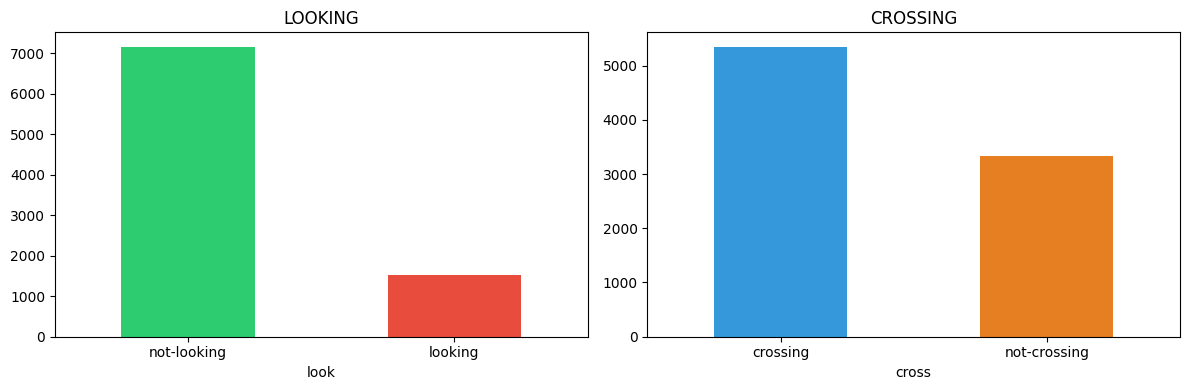

In [8]:
df = pd.DataFrame(all_entries)
df.to_csv(f'{DATASET_DIR}/labels.csv', index=False)
print(f"Total crops : {len(df)} | vidéos sources : {df['video'].nunique()}")
print("\nLOOK :\n", df['look'].value_counts())
print("\nCROSS :\n", df['cross'].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['look'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'], title='LOOKING')
df['cross'].value_counts().plot(kind='bar', ax=ax[1], color=['#3498db', '#e67e22'], title='CROSSING')
for a in ax: a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/dataset_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

In [9]:
CROPS_ZIP = f'{DATASET_DIR}/crops.zip'
print("Compression des crops locaux (1 seul fichier)...")
shutil.make_archive('/content/crops_archive', 'zip', LOCAL_CROPS)
shutil.move('/content/crops_archive.zip', CROPS_ZIP)
print(f"Archive créée : {CROPS_ZIP} ({os.path.getsize(CROPS_ZIP)/1e6:.0f} Mo)")
print("   -> au prochain démarrage de Colab, elle sera restaurée automatiquement (Partie 5).")

Compression des crops locaux (1 seul fichier)...
Archive créée : /content/drive/MyDrive/pedestrian_detection/dataset/crops.zip (49 Mo)
   -> au prochain démarrage de Colab, elle sera restaurée automatiquement (Partie 5).


In [10]:
CROPS_ZIP = f'{DATASET_DIR}/crops.zip'
local_vide = (not os.path.exists(LOCAL_CROPS)) or (len(os.listdir(LOCAL_CROPS)) == 0)
if local_vide and os.path.exists(CROPS_ZIP):
    os.makedirs(LOCAL_CROPS, exist_ok=True)
    print("Restauration des crops depuis l'archive Drive...")
    with zipfile.ZipFile(CROPS_ZIP) as z:
        z.extractall(LOCAL_CROPS)
    print(f"{len(os.listdir(LOCAL_CROPS))} crops restaurés en local")

def nb_jpg(d):
    return len([f for f in os.listdir(d) if f.endswith('.jpg')]) if os.path.exists(d) else 0
CROPS_DIR = LOCAL_CROPS if nb_jpg(LOCAL_CROPS) >= nb_jpg(DRIVE_CROPS) else DRIVE_CROPS
print(f"Dossier crops utilisé : {CROPS_DIR}  ({nb_jpg(CROPS_DIR)} images)")

df = pd.read_csv(f'{DATASET_DIR}/labels.csv')
avant = len(df)
df = df[df['filename'].apply(lambda f: os.path.exists(os.path.join(CROPS_DIR, f)))].reset_index(drop=True)
manquantes = avant - len(df)
if manquantes:
    print(f"{manquantes} images listées dans labels.csv sont introuvables → ignorées.")
    if manquantes > 0.05 * avant:
        print(" Beaucoup d'images manquent : relance l'extraction (Partie 4) "
              "puis recrée l'archive .zip avant de continuer.")
print(f"Images réellement disponibles : {len(df)}")
assert len(df) > 0, "Aucune image trouvée : relance la Partie 4 (extraction des crops)."

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(df, groups=df['video']))
train_df, temp_df = df.iloc[train_idx], df.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['video']))
val_df, test_df = temp_df.iloc[val_idx], temp_df.iloc[test_idx]

assert not (set(train_df['video']) & set(test_df['video'])), "Fuite test !"
assert not (set(train_df['video']) & set(val_df['video'])),  "Fuite val !"

for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{name:5} : {len(d):5} images | {d['video'].nunique():3} vidéos "
          f"| looking={(d['look']=='looking').mean()*100:.1f}%")

train_df.to_csv(f'{DATASET_DIR}/train.csv', index=False)
val_df.to_csv(f'{DATASET_DIR}/val.csv', index=False)
test_df.to_csv(f'{DATASET_DIR}/test.csv', index=False)
print("\n Splits par vidéo sauvegardés (uniquement des images existantes).")

Dossier crops utilisé : /content/dataset/crops  (8676 images)
Images réellement disponibles : 8676
Train :  5642 images | 219 vidéos | looking=18.3%
Val   :  1676 images |  47 vidéos | looking=14.1%
Test  :  1358 images |  48 vidéos | looking=17.9%

 Splits par vidéo sauvegardés (uniquement des images existantes).


In [11]:
CROPS_ZIP = f'{DATASET_DIR}/crops.zip'
if ((not os.path.exists(LOCAL_CROPS)) or len(os.listdir(LOCAL_CROPS)) == 0) and os.path.exists(CROPS_ZIP):
    os.makedirs(LOCAL_CROPS, exist_ok=True)
    with zipfile.ZipFile(CROPS_ZIP) as z:
        z.extractall(LOCAL_CROPS)
    print(f"Crops restaurés en local : {len(os.listdir(LOCAL_CROPS))}")

def _nb_jpg(d):
    return len([f for f in os.listdir(d) if f.endswith('.jpg')]) if os.path.exists(d) else 0
CROPS_DIR = LOCAL_CROPS if _nb_jpg(LOCAL_CROPS) >= _nb_jpg(DRIVE_CROPS) else DRIVE_CROPS
print("Crops utilisés :", CROPS_DIR, f"({_nb_jpg(CROPS_DIR)} images)")

train_df = pd.read_csv(f'{DATASET_DIR}/train.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test.csv')
print(f"Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")

Crops utilisés : /content/dataset/crops (8676 images)
Train 5642 | Val 1676 | Test 1358


In [12]:
class PedestrianDataset(Dataset):
    LOOK_MAP  = {'not-looking': 0, 'looking': 1}
    CROSS_MAP = {'not-crossing': 0, 'crossing': 1}

    def __init__(self, df, crops_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.crops_dir = crops_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.crops_dir, row['filename'])).convert('RGB')
        if self.transform:
            image = self.transform(image)

        label_look  = self.LOOK_MAP.get(row['look'], 0)
        label_cross = self.CROSS_MAP.get(row['cross'], 0)
        return image, label_look, label_cross

NORM = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), NORM])
eval_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), NORM])

def _keep_existing(d):
    m = d['filename'].apply(lambda f: os.path.exists(os.path.join(CROPS_DIR, f)))
    if (~m).any():
        print(f"  {(~m).sum()} image(s) introuvable(s) ignorée(s) dans un split")
    return d[m].reset_index(drop=True)
train_df = _keep_existing(train_df)
val_df   = _keep_existing(val_df)
test_df  = _keep_existing(test_df)

train_dataset = PedestrianDataset(train_df, CROPS_DIR, train_transform)
val_dataset   = PedestrianDataset(val_df,   CROPS_DIR, eval_transform)
test_dataset  = PedestrianDataset(test_df,  CROPS_DIR, eval_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"DataLoaders OK | train {len(train_loader)} batches")

DataLoaders OK | train 89 batches


In [13]:
class PedestrianBehaviorNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        resnet = models.resnet18(weights=weights)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        def head():
            return nn.Sequential(nn.Flatten(), nn.Linear(512, 128), nn.ReLU(),
                                 nn.Dropout(0.3), nn.Linear(128, 2))
        self.head_looking  = head()
        self.head_crossing = head()

    def forward(self, x):
        f = self.backbone(x)
        return self.head_looking(f), self.head_crossing(f)

model = PedestrianBehaviorNet(pretrained=True).to(device)
print("Modèle créé | paramètres :", f"{sum(p.numel() for p in model.parameters()):,}")

Modèle créé | paramètres : 11,308,356


In [14]:
def class_weights(series, mapping):
    y = series.map(mapping).values
    w = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
    return torch.tensor(w, dtype=torch.float32).to(device)

look_w  = class_weights(train_df['look'],  PedestrianDataset.LOOK_MAP)
cross_w = class_weights(train_df['cross'], PedestrianDataset.CROSS_MAP)
print("Poids LOOKING :", look_w.tolist(), "| CROSSING :", cross_w.tolist())

class FocalLoss(nn.Module):
    """Insiste sur les exemples difficiles + tient compte des poids de classes (alpha)."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__(); self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

criterion_look  = FocalLoss(alpha=look_w,  gamma=2.0)
criterion_cross = FocalLoss(alpha=cross_w, gamma=2.0)
print("Focal Loss prête (pas d'oversampling en plus → pas de double correction).")

Poids LOOKING : [0.6123290657997131, 2.7256038188934326] | CROSSING : [1.3350685834884644, 0.7993766069412231]
Focal Loss prête (pas d'oversampling en plus → pas de double correction).


In [15]:
def train_one_epoch(model, loader, optimizer, c_look, c_cross, device, alpha=0.5):
    model.train()
    tot_loss = correct_look = correct_cross = total = 0
    for images, y_look, y_cross in loader:
        images, y_look, y_cross = images.to(device), y_look.to(device), y_cross.to(device)
        out_look, out_cross = model(images)
        loss = alpha * c_look(out_look, y_look) + (1 - alpha) * c_cross(out_cross, y_cross)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tot_loss += loss.item()
        correct_look  += (out_look.argmax(1)  == y_look).sum().item()
        correct_cross += (out_cross.argmax(1) == y_cross).sum().item()
        total += y_look.size(0)
    return tot_loss/len(loader), 100*correct_look/total, 100*correct_cross/total

@torch.no_grad()
def evaluate(model, loader, c_look, c_cross, device, alpha=0.5):
    model.eval()
    tot_loss = correct_look = correct_cross = total = 0
    P_look, Y_look, P_cross, Y_cross = [], [], [], []
    for images, y_look, y_cross in loader:
        images, y_look, y_cross = images.to(device), y_look.to(device), y_cross.to(device)
        out_look, out_cross = model(images)
        loss = alpha * c_look(out_look, y_look) + (1 - alpha) * c_cross(out_cross, y_cross)
        tot_loss += loss.item()
        p_look, p_cross = out_look.argmax(1), out_cross.argmax(1)
        correct_look  += (p_look  == y_look).sum().item()
        correct_cross += (p_cross == y_cross).sum().item()
        total += y_look.size(0)
        P_look += p_look.cpu().tolist();  Y_look += y_look.cpu().tolist()
        P_cross += p_cross.cpu().tolist(); Y_cross += y_cross.cpu().tolist()
    return (tot_loss/len(loader), 100*correct_look/total, 100*correct_cross/total,
            P_look, Y_look, P_cross, Y_cross)

print("Fonctions train/evaluate prêtes.")

Fonctions train/evaluate prêtes.


In [16]:
EPOCHS, ALPHA, PATIENCE = 20, 0.5, 5
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {k: [] for k in ['train_loss','val_loss','val_acc_look','val_acc_cross']}
best_f1, patience = 0.0, 0
BEST_PATH = f'{MODELS_DIR}/best_model.pth'
print("Entraînement\n")

for epoch in range(EPOCHS):
    t = time.time()
    tr_loss, tr_look, tr_cross = train_one_epoch(model, train_loader, optimizer,
                                                 criterion_look, criterion_cross, device, ALPHA)
    va_loss, va_look, va_cross, p_look, y_look, _, _ = evaluate(model, val_loader,
                                                 criterion_look, criterion_cross, device, ALPHA)
    scheduler.step()
    f1 = f1_score(y_look, p_look, pos_label=1, zero_division=0)
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['val_acc_look'].append(va_look); history['val_acc_cross'].append(va_cross)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | loss {tr_loss:.3f}/{va_loss:.3f} | "
          f"Look {va_look:.1f}% | Cross {va_cross:.1f}% | F1-look {f1:.3f} | {time.time()-t:.0f}s")

    if f1 > best_f1:
        best_f1, patience = f1, 0
        torch.save(model.state_dict(), BEST_PATH)
        print(f"sauvegardé (F1-look {f1:.3f})")
    else:
        patience += 1
        if patience >= PATIENCE:
            print("\n Early stopping"); break

print(f"\n Terminé | meilleur F1-looking : {best_f1:.3f}")

Entraînement

Epoch  1/20 | loss 0.160/0.169 | Look 52.6% | Cross 61.8% | F1-look 0.359 | 14s
sauvegardé (F1-look 0.359)
Epoch  2/20 | loss 0.100/0.178 | Look 62.2% | Cross 67.7% | F1-look 0.398 | 14s
sauvegardé (F1-look 0.398)
Epoch  3/20 | loss 0.069/0.205 | Look 70.7% | Cross 69.3% | F1-look 0.435 | 14s
sauvegardé (F1-look 0.435)
Epoch  4/20 | loss 0.050/0.209 | Look 70.5% | Cross 66.7% | F1-look 0.454 | 14s
sauvegardé (F1-look 0.454)
Epoch  5/20 | loss 0.031/0.367 | Look 81.8% | Cross 66.8% | F1-look 0.493 | 14s
sauvegardé (F1-look 0.493)
Epoch  6/20 | loss 0.026/0.329 | Look 81.6% | Cross 68.3% | F1-look 0.491 | 14s
Epoch  7/20 | loss 0.016/0.349 | Look 84.0% | Cross 69.7% | F1-look 0.520 | 15s
sauvegardé (F1-look 0.520)
Epoch  8/20 | loss 0.010/0.375 | Look 81.2% | Cross 71.3% | F1-look 0.493 | 14s
Epoch  9/20 | loss 0.014/0.342 | Look 83.7% | Cross 71.8% | F1-look 0.499 | 14s
Epoch 10/20 | loss 0.006/0.390 | Look 85.7% | Cross 71.8% | F1-look 0.532 | 14s
sauvegardé (F1-look 0.53

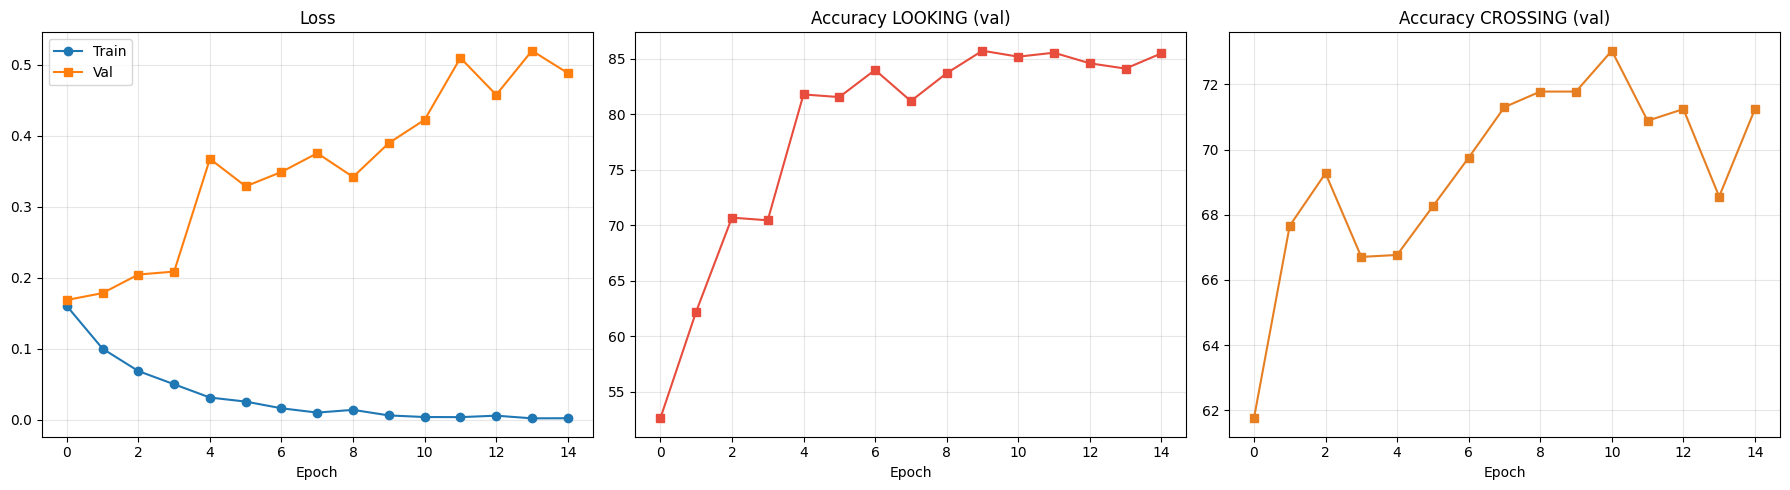

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(history['train_loss'], 'o-', label='Train'); ax[0].plot(history['val_loss'], 's-', label='Val')
ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history['val_acc_look'], 's-', color='#e74c3c'); ax[1].set_title('Accuracy LOOKING (val)'); ax[1].grid(alpha=0.3)
ax[2].plot(history['val_acc_cross'], 's-', color='#e67e22'); ax[2].set_title('Accuracy CROSSING (val)'); ax[2].grid(alpha=0.3)
for a in ax: a.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

RÉSULTATS SUR LE TEST (sans fuite de données)

 LOOKING — accuracy 83.8%
              precision    recall  f1-score   support

 not-looking       0.91      0.89      0.90      1115
     looking       0.54      0.61      0.57       243

    accuracy                           0.84      1358
   macro avg       0.73      0.75      0.74      1358
weighted avg       0.85      0.84      0.84      1358

 CROSSING — accuracy 77.7%
              precision    recall  f1-score   support

not-crossing       0.69      0.75      0.72       519
    crossing       0.84      0.79      0.81       839

    accuracy                           0.78      1358
   macro avg       0.76      0.77      0.77      1358
weighted avg       0.78      0.78      0.78      1358



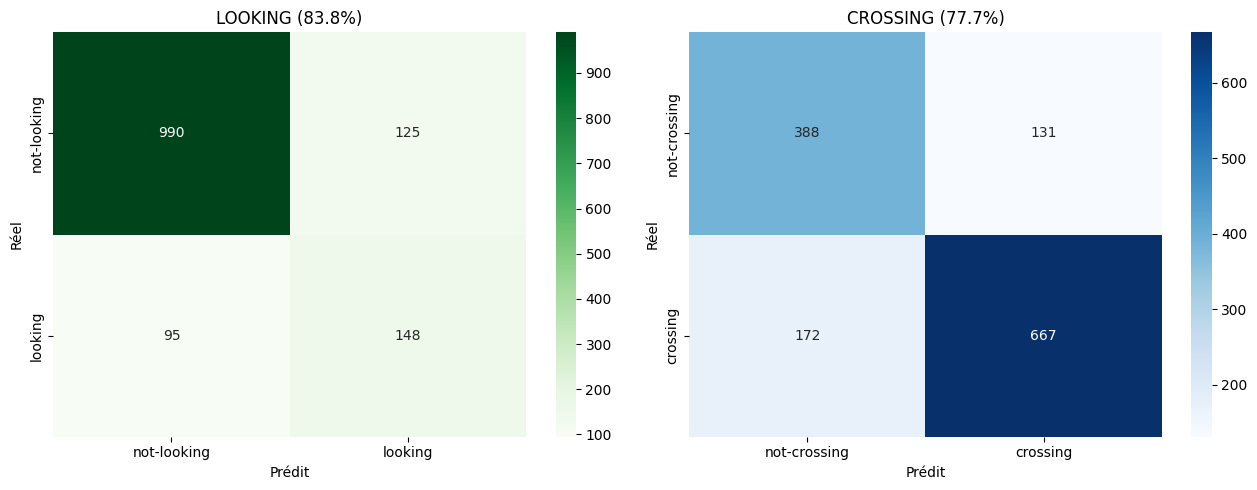

In [18]:
model.load_state_dict(torch.load(BEST_PATH))
_, acc_look, acc_cross, p_look, y_look, p_cross, y_cross = evaluate(
    model, test_loader, criterion_look, criterion_cross, device, ALPHA)

print("="*60, "\nRÉSULTATS SUR LE TEST (sans fuite de données)\n", "="*60, sep='')
print(f"\n LOOKING — accuracy {acc_look:.1f}%")
print(classification_report(y_look, p_look, target_names=['not-looking', 'looking'], zero_division=0))
print(f" CROSSING — accuracy {acc_cross:.1f}%")
print(classification_report(y_cross, p_cross, target_names=['not-crossing', 'crossing'], zero_division=0))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(confusion_matrix(y_look, p_look), annot=True, fmt='d', cmap='Greens',
            xticklabels=['not-looking','looking'], yticklabels=['not-looking','looking'], ax=ax[0])
ax[0].set_title(f'LOOKING ({acc_look:.1f}%)'); ax[0].set_xlabel('Prédit'); ax[0].set_ylabel('Réel')
sns.heatmap(confusion_matrix(y_cross, p_cross), annot=True, fmt='d', cmap='Blues',
            xticklabels=['not-crossing','crossing'], yticklabels=['not-crossing','crossing'], ax=ax[1])
ax[1].set_title(f'CROSSING ({acc_cross:.1f}%)'); ax[1].set_xlabel('Prédit'); ax[1].set_ylabel('Réel')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()

In [19]:
LOOK_NAMES  = {0: 'not-looking', 1: 'looking'}
CROSS_NAMES = {0: 'not-crossing', 1: 'crossing'}

infer_model = PedestrianBehaviorNet(pretrained=False).to(device)
infer_model.load_state_dict(torch.load(f'{MODELS_DIR}/best_model.pth', map_location=device))
infer_model.eval()

@torch.no_grad()
def predict_pedestrian(crop_bgr):
    """crop_bgr = image OpenCV (BGR) d'un seul piéton. Retourne les 2 prédictions + confiances."""
    img = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    x = eval_transform(img).unsqueeze(0).to(device)
    out_look, out_cross = infer_model(x)
    pl = torch.softmax(out_look, 1)[0];  pc = torch.softmax(out_cross, 1)[0]
    il, ic = int(pl.argmax()), int(pc.argmax())
    return {'look': LOOK_NAMES[il], 'look_conf': float(pl[il]),
            'cross': CROSS_NAMES[ic], 'cross_conf': float(pc[ic])}

def draw_prediction(frame, x1, y1, x2, y2, pred):
    """Dessine le rectangle + le texte des prédictions sur l'image."""

    danger = (pred['look'] == 'not-looking' and pred['cross'] == 'crossing')
    color = (0, 0, 255) if danger else (0, 200, 0)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    txt = f"{pred['look']} {pred['look_conf']*100:.0f}% | {pred['cross']} {pred['cross_conf']*100:.0f}%"
    cv2.rectangle(frame, (x1, y1-22), (x1+len(txt)*7, y1), color, -1)
    cv2.putText(frame, txt, (x1+2, y1-6), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)
    return frame

print("Outils d'inférence prêts.")

Outils d'inférence prêts.


In [20]:
DEMO_VIDEO = 'video_0001'
OUT_PATH   = f'{PROJECT_DIR}/demo_{DEMO_VIDEO}_pred.mp4'

ann = parse_jaad_xml_fast(f'{ANNOTATIONS_DIR}/{DEMO_VIDEO}.xml', frame_skip=1)
cap = cv2.VideoCapture(f'{VIDEOS_DIR}/{DEMO_VIDEO}.mp4')
fps = cap.get(cv2.CAP_PROP_FPS) or 30
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
writer = cv2.VideoWriter(OUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    for a in ann.get(frame_idx, []):
        crop = frame[max(0,a['y1']):a['y2'], max(0,a['x1']):a['x2']]
        if crop.size:
            draw_prediction(frame, a['x1'], a['y1'], a['x2'], a['y2'], predict_pedestrian(crop))
    writer.write(frame); frame_idx += 1
cap.release(); writer.release()
print(f"Vidéo annotée enregistrée : {OUT_PATH}")

Vidéo annotée enregistrée : /content/drive/MyDrive/pedestrian_detection/demo_video_0001_pred.mp4
